In [ ]:
from google.colab import files
uploaded = files.upload()

Saving thermal.jpg to thermal.jpg


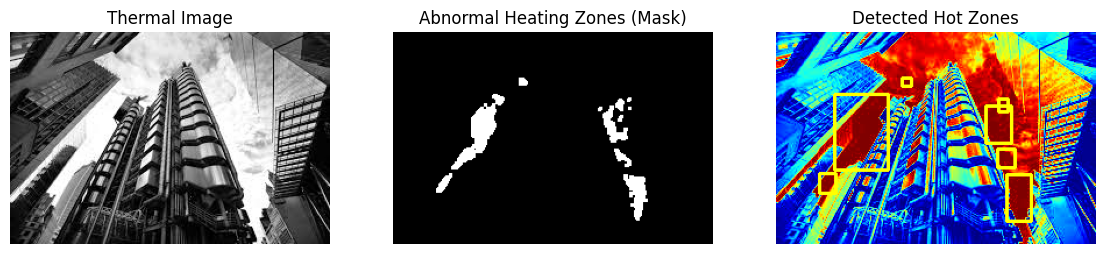

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def detect_abnormal_heating(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Image not found or cannot be opened: {image_path}")
    blur = cv2.GaussianBlur(img, (5, 5), 0)
    thresh_val = np.percentile(blur, 95)
    _, hot_mask = cv2.threshold(
        blur, int(thresh_val), 255, cv2.THRESH_BINARY
    )

    kernel = np.ones((3, 3), np.uint8)
    hot_clean = cv2.morphologyEx(hot_mask, cv2.MORPH_OPEN, kernel, iterations=1)
    heatmap = cv2.applyColorMap(img, cv2.COLORMAP_JET)
    contours, _ = cv2.findContours(
        hot_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    output = heatmap.copy()
    for cnt in contours:
        if cv2.contourArea(cnt) < 20:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 255), 2)
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Thermal Image")
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.imshow(hot_clean, cmap="gray")
    plt.title("Abnormal Heating Zones (Mask)")
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.title("Detected Hot Zones")
    plt.axis("off")
    plt.show()
detect_abnormal_heating("thermal.jpg")
